# <center> Exercise 5 Classification Tree

In [208]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from fractions import Fraction
sb.set()

## Problem 1

In [209]:
houseData = pd.read_csv('train.csv')
SalePrice = pd.DataFrame(houseData["SalePrice"])
CentralAir = pd.DataFrame(houseData["CentralAir"])

Y    1365
N      95
Name: CentralAir, dtype: int64

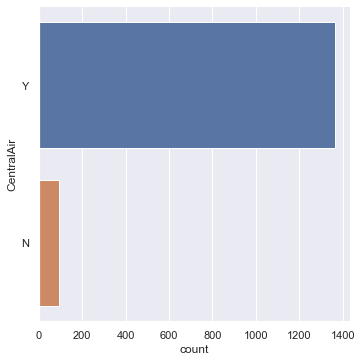

In [210]:
# Plot the distribution of CentralAir to check the imbalance of Y against N. Print the ratio of the classes Y : N
sb.catplot(y = "CentralAir", data = CentralAir, kind = "count")
CentralAir["CentralAir"].value_counts()

D:\Anaconda\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 24.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


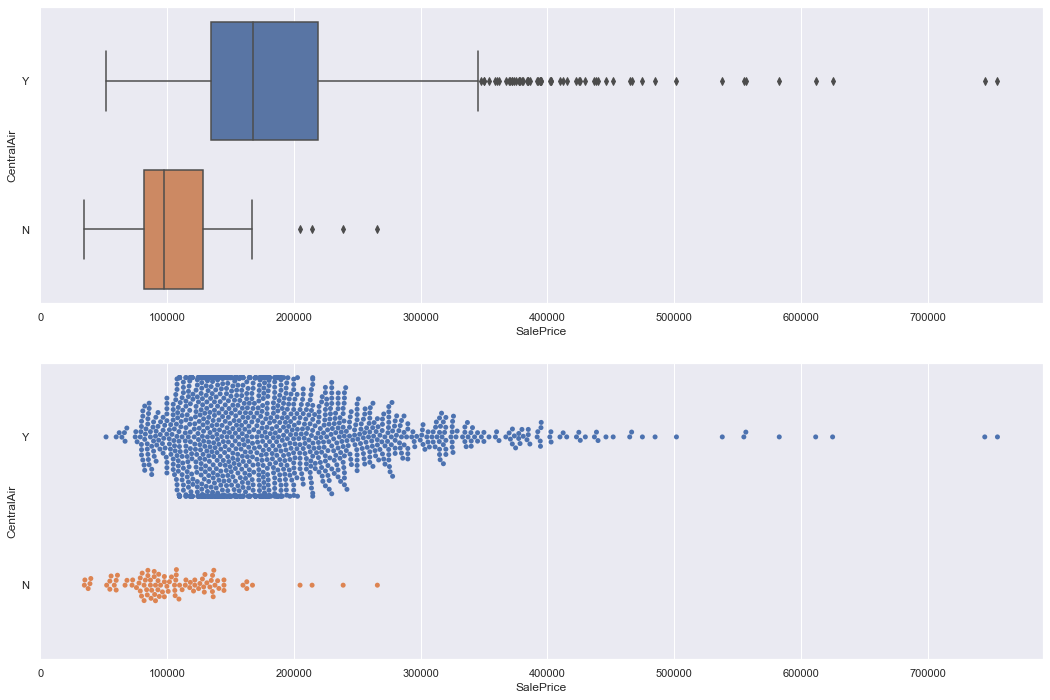

In [211]:
# Plot CentralAir against SalePrice using any appropriate bivariate plot to note the mutual relationship.
trainDF = pd.concat([SalePrice, CentralAir], axis = 1).reindex(CentralAir.index)

f, axes = plt.subplots(2, 1, figsize = (18, 12))
sb.boxplot(x = "SalePrice", y = "CentralAir", data = trainDF, orient = "h", ax = axes[0])
sb.swarmplot(x = "SalePrice", y = "CentralAir", data = trainDF, orient = "h", ax = axes[1])
plt.show()

In [212]:
# Import Classification Tree model from Scikit-Learn : from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

# Partition the dataset houseData into two “random” portions : Train Data (1100 rows) and Test Data (360 rows).
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(SalePrice, CentralAir, train_size=1100, test_size=360)

# Training : Fit a Decision Tree model on the Train Dataset to predict the class (Y/N) of CentralAir using SalePrice.
dectree = DecisionTreeClassifier(max_depth = 3)
dectree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

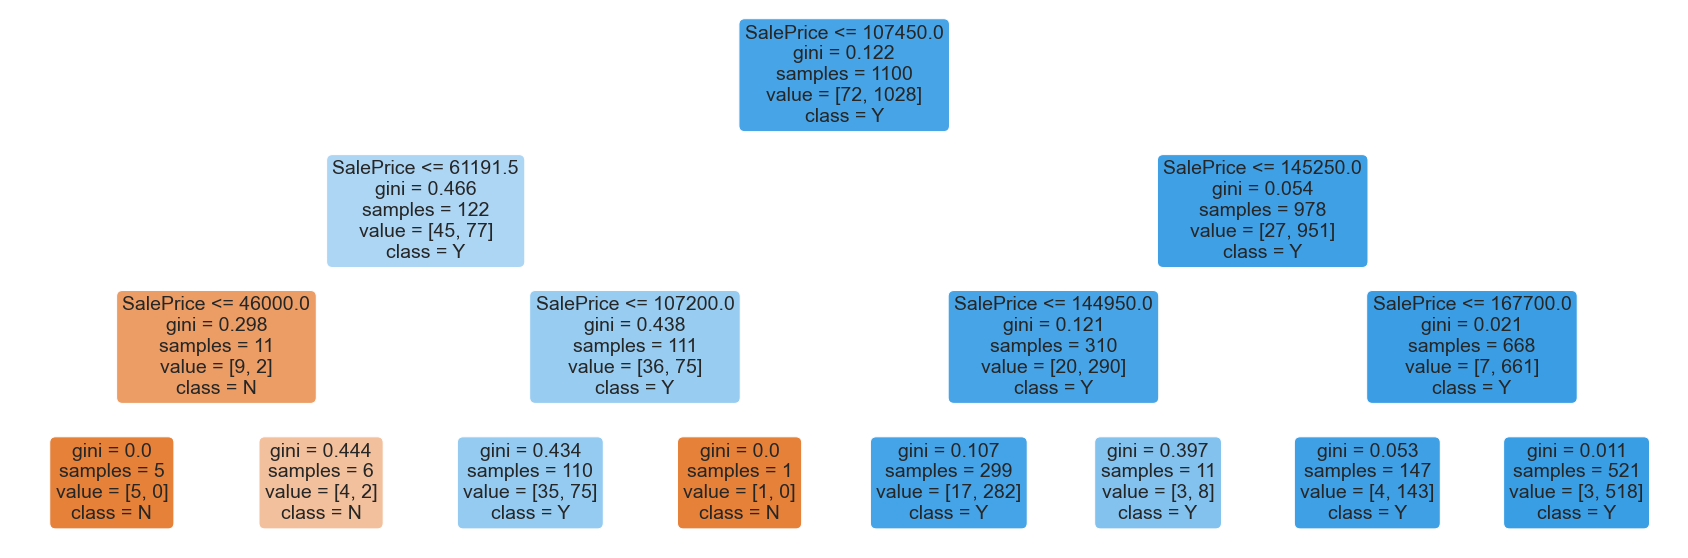

In [213]:
# Visualize the Decision Tree model
from sklearn.tree import plot_tree

f = plt.figure(figsize=(30, 10))
plot_tree(dectree, filled=True, rounded=True, 
          feature_names=["SalePrice"], 
          class_names=["N","Y"])
plt.show()

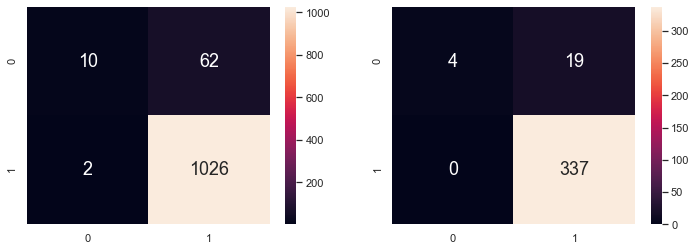

In [214]:
# Predict CentralAir for the train and test dataset using the Decision Tree model and plot the Two-Way Confusion Matrix
from sklearn.metrics import confusion_matrix
y_train_pred = dectree.predict(x_train)
y_test_pred = dectree.predict(x_test)

f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])
plt.show()

In [215]:
# Function to calculate accurary measures
def accuracy(arr):
    TN = arr[0][0]
    TP = arr[1][1]
    FP = arr[0][1]
    FN = arr[1][0]
    TPR = TP/(TP + FN)
    TNR = TN/(TN + FP)
    FNR = FN/(FN + TP)
    FPR = FP/(FP + TN)
    ACC = (TP + TN)/(TP + TN + FP + FN)
    
    attr = [ACC, TPR,  TNR, FPR, FNR]
    return attr
    
    
def make_df(arr1, arr2):   
    data = { "train data": accuracy(arr1), "test data": accuracy(arr2) }      
    return pd.DataFrame(data, index = ['Classification Accuracy','True Positive Rate','True Negative Rate','False Positive Rate','False Negative Rate'])

In [216]:
# Print accuracy measures of the Decision Tree model, including its Classification Accuracy, True Positive Rate,
# True Negative Rate, False Positive Rate and False Negative Rate, based on the confusion matrix on train data.
para = []
arr1 = confusion_matrix(y_train, y_train_pred)
arr2 = confusion_matrix(y_test, y_test_pred)

para.append(make_df(arr1, arr2))
make_df(arr1, arr2)

,train data,test data
Classification Accuracy,0.941818,0.947222
True Positive Rate,0.998054,1.000000
True Negative Rate,0.138889,0.173913
False Positive Rate,0.861111,0.826087
False Negative Rate,0.001946,0.000000


## Problem 2

In [217]:
var = ['GrLivArea', 'OverallQual', 'YearBuilt']

### Bivariate plot 

D:\Anaconda\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 29.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
D:\Anaconda\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 89.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
D:\Anaconda\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 17.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
D:\Anaconda\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 20.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


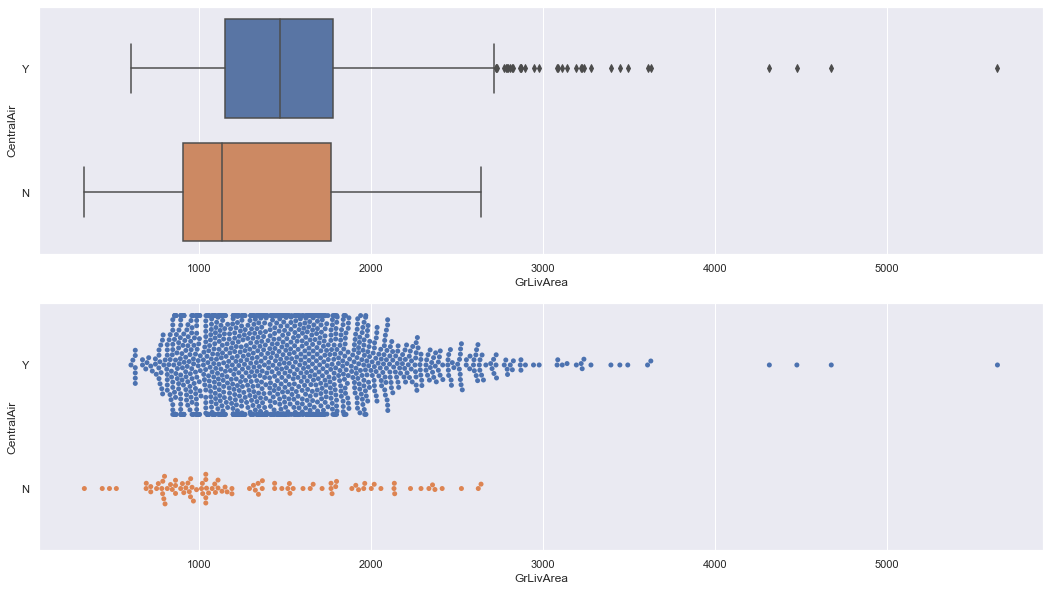

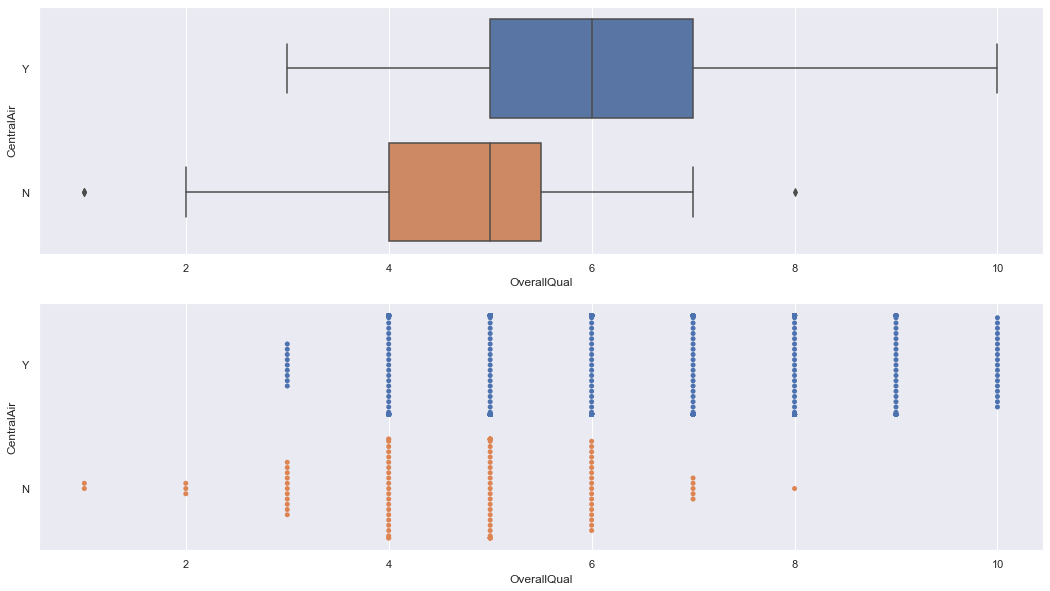

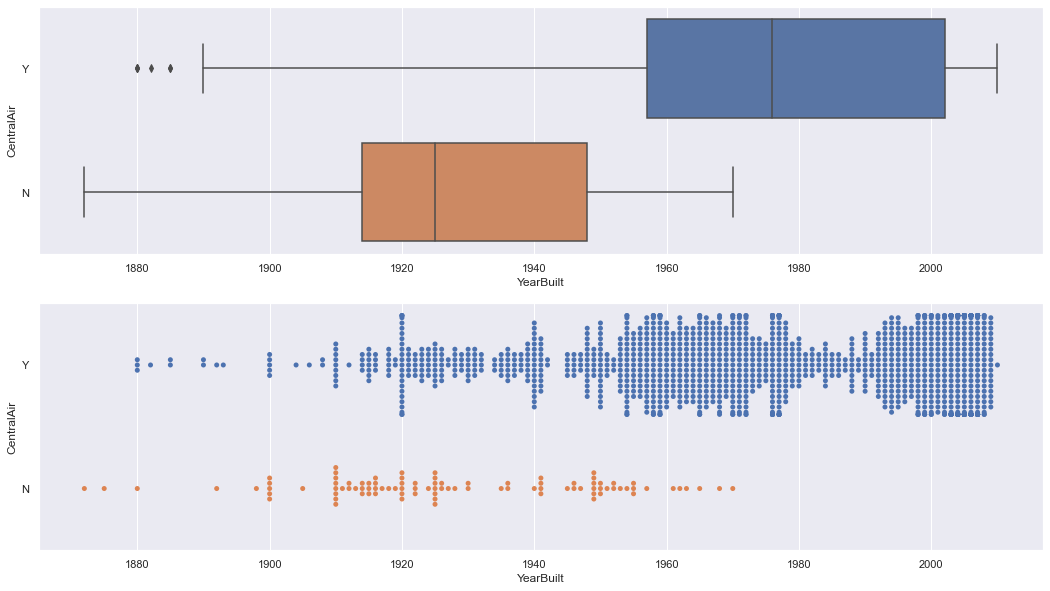

In [218]:
for item in var:
    d = pd.DataFrame(houseData[item])
    trainDF = pd.concat([CentralAir, d], axis = 1).reindex(d.index)
    f, axes = plt.subplots(2, 1, figsize = (18, 10))
    sb.boxplot(x = item, y = "CentralAir", data = trainDF, orient = "h", ax = axes[0])
    sb.swarmplot(y = "CentralAir", x = item, data = trainDF, orient = "h")

### Modeling and Visualizing

In [219]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix

GrLivArea
------------------------------------------------------------------------------------------------------------------------


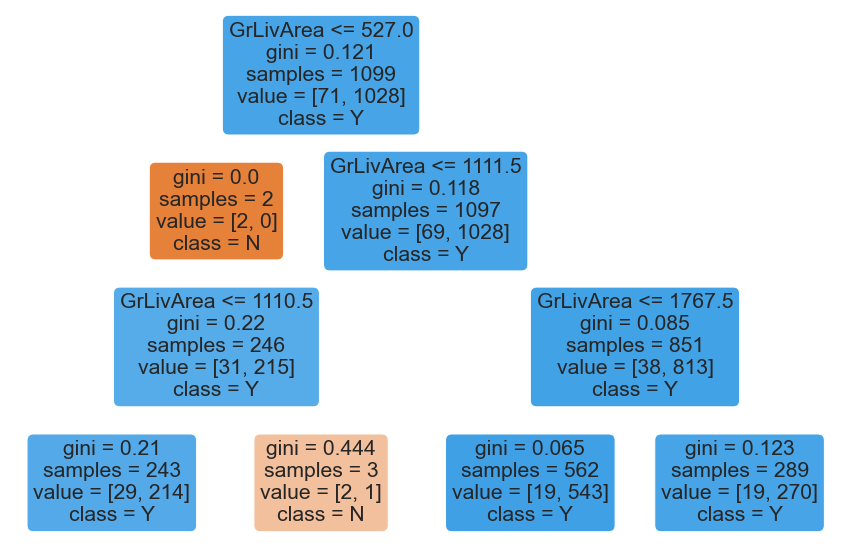

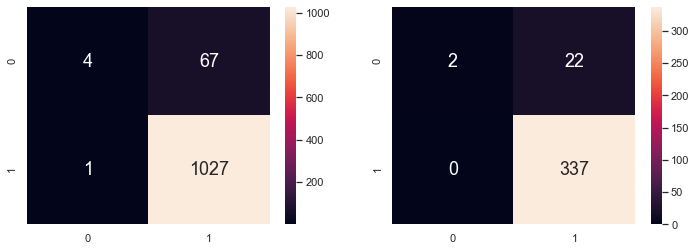

                         train data  test data
Classification Accuracy    0.938126   0.939058
True Positive Rate         0.999027   1.000000
True Negative Rate         0.056338   0.083333
False Positive Rate        0.943662   0.916667
False Negative Rate        0.000973   0.000000


OverallQual
------------------------------------------------------------------------------------------------------------------------


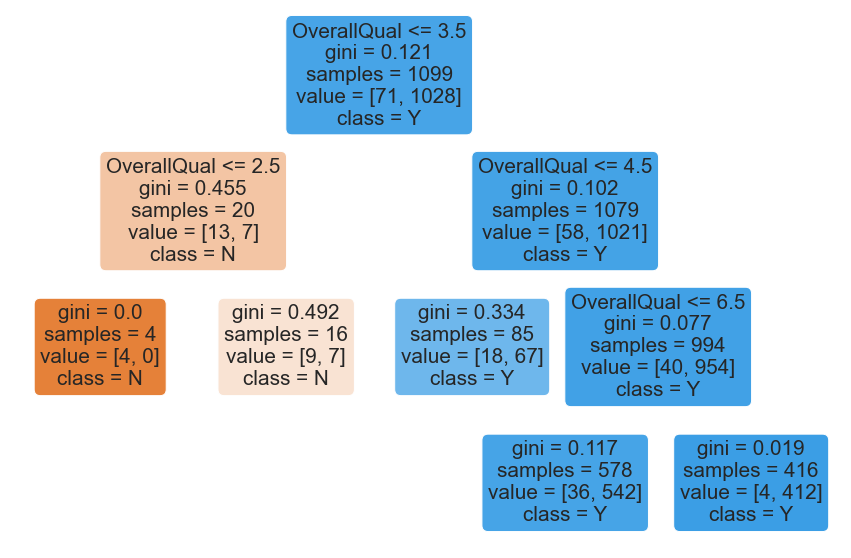

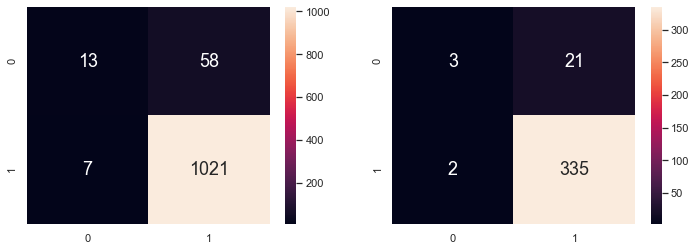

                         train data  test data
Classification Accuracy    0.940855   0.936288
True Positive Rate         0.993191   0.994065
True Negative Rate         0.183099   0.125000
False Positive Rate        0.816901   0.875000
False Negative Rate        0.006809   0.005935


YearBuilt
------------------------------------------------------------------------------------------------------------------------


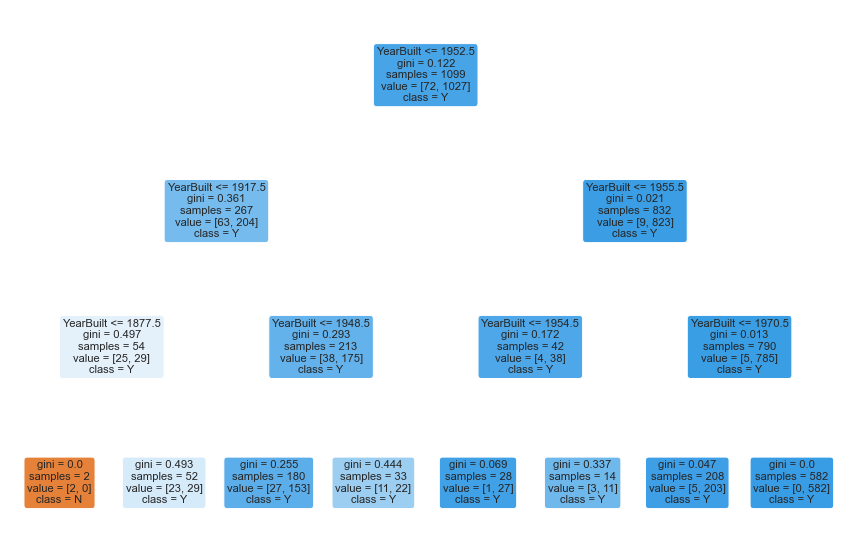

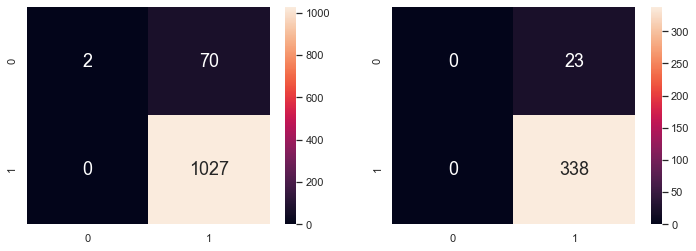

                         train data  test data
Classification Accuracy    0.936306   0.936288
True Positive Rate         1.000000   1.000000
True Negative Rate         0.027778   0.000000
False Positive Rate        0.972222   1.000000
False Negative Rate        0.000000   0.000000




In [220]:

for item in var:
    print(item)
    print("-"*120)
    d = pd.DataFrame(houseData[item])
    x_train, x_test, y_train, y_test = train_test_split(d, CentralAir, test_size = 0.2465753425)
    dectree = DecisionTreeClassifier(max_depth = 3)
    dectree.fit(x_train, y_train)
    y_train_pred = dectree.predict(x_train)
    y_test_pred = dectree.predict(x_test)
    
    f = plt.figure(figsize=(15, 10))
    plot_tree(dectree, filled=True, rounded=True, 
              feature_names=[item], 
              class_names=["N","Y"])
    plt.show()    
    print()
    f, axes = plt.subplots(1, 2, figsize=(12, 4))
    sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
    sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])
    plt.show()
    arr1 = confusion_matrix(y_train, y_train_pred)
    arr2 = confusion_matrix(y_test, y_test_pred)
    para.append(make_df(arr1, arr2))
    print(make_df(arr1, arr2))
    print()
    print()

 ## Problem 3

In [221]:
# Display the attributes of variables
i = 0
var = ['SalePrice', 'GrLivArea', 'OverallQual', 'YearBuilt']
for item in var:
    print(item)
    print(para[i])
    print()
    i+=1

SalePrice
                         train data  test data
Classification Accuracy    0.941818   0.947222
True Positive Rate         0.998054   1.000000
True Negative Rate         0.138889   0.173913
False Positive Rate        0.861111   0.826087
False Negative Rate        0.001946   0.000000

GrLivArea
                         train data  test data
Classification Accuracy    0.938126   0.939058
True Positive Rate         0.999027   1.000000
True Negative Rate         0.056338   0.083333
False Positive Rate        0.943662   0.916667
False Negative Rate        0.000973   0.000000

OverallQual
                         train data  test data
Classification Accuracy    0.940855   0.936288
True Positive Rate         0.993191   0.994065
True Negative Rate         0.183099   0.125000
False Positive Rate        0.816901   0.875000
False Negative Rate        0.006809   0.005935

YearBuilt
                         train data  test data
Classification Accuracy    0.936306   0.936288
True Positive R

By comparisons of models above, we can concluded:  

From Classification Accuracy, four models are equally accurate for classification for both high train and test data, which indicated it is suitable to apply a Decision Tree.    

From $\text{FPR}$ and $\text{TNR}$, four models tend to be quite accurate when predicting positive results, the $\text{FPR}$ are much higher than the $\text{TNR}$. As for the weak negativity prediction, partially because of a low ratio of N (Negative) Samples in the total Sample. i.e.Y:N = $273:19$.  

We rank the four models:  
`SalePrice` > `GrLivArea`/ `OverallQual` > `YearBuilt`  
`SalePrice`. in its decision tree, the leaf node predicting negative results also has a higher sample count and lower gini index (in general).  
`GrLivArea` and `OverallQual`: both the trees and the accuracy measures, and the results tend to be slighly less reliable than that of `SalePrice`.
`YearBuilt`: its decision tree does not even contain nodes that can produce negative results, resulting in $\text{TPR} = 1$ and $\text{TNR} = 0$. That would not be reliable at all.